# Personal Information
Name: **Alexandra Holíková**

StudentID: **14236788**

Email: [**alexandra.holikova@student.uva.nl**](alexandra.holikova@student.uva.nl)

Github link: https://github.com/alexandraholik/MSc_Thesis.git

# 05b — Korean Evaluation: Quote-to-Quote Condition

Adds the quote-to-quote (q2q) input condition to the Korean evaluation.
All existing results (sentence window, full article, language variants) are loaded
from `data/korean_predictions.csv`. Only the two new q2q GPT conditions are run here.

Song et al. (2023) QuoteCSE operates quote-to-quote: the headline quote is compared
against the most similar body quote. This notebook replicates that input scope
for the GPT-4o approaches, enabling a direct like-for-like comparison.

**New conditions:**
- Cosine (q2q) — cosine baseline on quote-level similarity
- GPT-4o Direct (q2q) — direct prompt, headline quote vs best body quote
- GPT-4o CoT (q2q) — CoT prompt, headline quote vs best body quote

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import warnings, re, openai, json, os, time
warnings.filterwarnings('ignore')
from dotenv import load_dotenv
load_dotenv()

THRESHOLD = 0.5

# Load all existing results
df = pd.read_csv('data/korean_predictions.csv')
df['label'] = df['label'].astype(int)
for col in ['prev_sentence', 'next_sentence', 'best_body_sentence']:
    df[col] = df[col].fillna('')

# Merge q2q columns from new matched file
df_q2q = pd.read_csv('data_new/korean_matched.csv')
df_q2q = df_q2q.rename(columns={
    'best_body_sentence': 'best_body_quote',
    'best_sim':           'best_quote_sim',
})[['url', 'best_body_quote', 'best_quote_sim']]
df = df.merge(df_q2q, on='url', how='left')
df['best_body_quote'] = df['best_body_quote'].fillna('')
df['best_quote_sim']  = df['best_quote_sim'].fillna(0.0)

y_true = df['label'].values
print(f'Loaded: {len(df)} articles')
print(f'Contextomized: {y_true.sum()}  |  Modified: {(y_true==0).sum()}')
print(f'Q2Q quotes joined: {(df["best_quote_sim"] > 0).sum()} / {len(df)}')

Loaded: 1600 articles
Contextomized: 814  |  Modified: 786
Q2Q quotes joined: 1599 / 1600


In [3]:
def evaluate(y_true, scores, threshold=THRESHOLD, name=''):
    preds = (scores >= threshold).astype(int)
    auc   = roc_auc_score(y_true, scores)
    f1    = f1_score(y_true, preds, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0
    print(f"{'=== ' + name + ' ===' if name else ''}")
    print(f'AUC: {auc:.3f}  |  F1: {f1:.3f}  |  Sens: {sensitivity:.3f}  |  Spec: {specificity:.3f}  |  Prec: {precision:.3f}')
    return preds, auc, f1, sensitivity, specificity, precision

In [4]:
# Reload all existing scores — no reruns needed
cosine_scores    = df['score_cosine'].values
cosine_preds     = df['pred_cosine'].values
nli_scores       = df['score_nli'].values
nli_preds        = df['pred_nli'].values
gpt_scores       = df['score_gpt'].values
gpt_preds        = df['pred_gpt'].values
cot_scores       = df['score_cot'].values
cot_preds        = df['pred_cot'].values
gpt_full_scores  = df['score_gpt_full'].values
gpt_full_preds   = df['pred_gpt_full'].values
cot_full_scores  = df['score_cot_full'].values
cot_full_preds   = df['pred_cot_full'].values
cot_ko_scores    = df['score_cot_ko'].values
cot_ko_preds     = df['pred_cot_ko'].values
cot_xlcot_scores = df['score_cot_xlcot'].values
cot_xlcot_preds  = df['pred_cot_xlcot'].values

print('Existing scores reloaded.')

Existing scores reloaded.


## Cosine Baseline (Quote-to-Quote)

In [5]:
cosine_q2q_scores = 1 - df['best_quote_sim'].values
cosine_q2q_preds, cosine_q2q_auc, cosine_q2q_f1, _, _, _ = evaluate(
    y_true, cosine_q2q_scores, name='Cosine (q2q)')

=== Cosine (q2q) ===
AUC: 0.809  |  F1: 0.603  |  Sens: 0.464  |  Spec: 0.922  |  Prec: 0.861


## GPT-4o Quote-to-Quote Conditions

In [9]:
client = openai.OpenAI(api_key=os.environ['OPENAI_API_KEY'])

SYSTEM_DIRECT = """You are a journalism ethics expert specialising in quote accuracy.

Definitions:
- MODIFIED: The headline quote faithfully preserves the speaker's intended meaning. Minor editorial changes are acceptable: grammatical adaptation, brevity, pronoun replacement, or paraphrase that does not alter what the speaker actually claimed.
- CONTEXTOMIZED: The headline quote distorts the speaker's intended meaning by removing qualifications, stripping hedges, omitting key context, or combining fragments in a way that produces a materially different claim than the speaker made.

The bar for CONTEXTOMIZED is semantic distortion, not surface difference. When in doubt, prefer MODIFIED.

You will receive a headline quote and the body text where it originated.
Output ONLY valid JSON with exactly two fields:
- \"label\": \"CONTEXTOMIZED\" or \"MODIFIED\"
- \"probability\": float 0.0-1.0, your estimated probability that the quote is contextomized"""

SYSTEM_COT = """You are a journalism ethics expert specialising in quote accuracy.

Definitions:
- MODIFIED: The headline quote faithfully preserves the speaker's meaning.
- CONTEXTOMIZED: The headline quote distorts the speaker's intended meaning by removing context, altering emphasis, or combining fragments in a misleading way.

Reason step by step, then output ONLY valid JSON with exactly four fields:
- \"step1\": What is the speaker's intended meaning in the body context? (1 sentence)
- \"step2\": Does the headline quote preserve or distort that meaning? (1 sentence)
- \"label\": \"CONTEXTOMIZED\" or \"MODIFIED\"
- \"probability\": float 0.0-1.0, your estimated probability that the quote is contextomized"""

def parse_response(text):
    text = text.strip().replace('```json','').replace('```','')
    try:
        parsed = json.loads(text)
    except json.JSONDecodeError:
        label_match = re.search(r'"label"\s*:\s*"(CONTEXTOMIZED|MODIFIED)"', text)
        prob_match  = re.search(r'"probability"\s*:\s*([0-9.]+)', text)
        if label_match and prob_match:
            return label_match.group(1), float(prob_match.group(1))
        raise
    return parsed['label'], float(parsed['probability'])

def run_gpt_q2q(df, system_prompt, max_tokens=60, desc=''):
    labels, scores = [], []
    for i, (_, row) in enumerate(df.iterrows()):
        try:
            user_msg = (f'HEADLINE QUOTE: "{row["headline_quote"]}"\n'
                f'BODY QUOTE: "{row["best_body_quote"]}"')
            response = client.chat.completions.create(
                model='gpt-4o',
                messages=[
                    {'role': 'system', 'content': system_prompt},
                    {'role': 'user',   'content': user_msg}
                ],
                temperature=0,
                max_tokens=max_tokens
            )
            label, prob = parse_response(response.choices[0].message.content)
            labels.append(1 if label == 'CONTEXTOMIZED' else 0)
            scores.append(prob)
        except Exception as e:
            print(f'Row {i} failed: {e}')
            labels.append(0)
            scores.append(0.5)
        if (i + 1) % 100 == 0:
            print(f'  [{desc}] {i+1}/{len(df)} done')
        time.sleep(0.3)
    return np.array(labels), np.array(scores)

# Pilot
print('Pilot (5 rows) — Direct q2q:')
for _, row in df.head(5).iterrows():
    user_msg = f'HEADLINE QUOTE: "{row["headline_quote"]}"\nBODY QUOTE: "{row["best_body_quote"]}"'
    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[{'role': 'system', 'content': SYSTEM_DIRECT},
                  {'role': 'user',   'content': user_msg}],
        temperature=0, max_tokens=60
    )
    label, prob = parse_response(response.choices[0].message.content)
    print(f'  gt={row["label"]}  pred={label}  prob={prob:.2f}  |  {str(row["headline_quote"])[:60]}')
    time.sleep(0.3)

Pilot (5 rows) — Direct q2q:
  gt=1  pred=CONTEXTOMIZED  prob=0.90  |  ['한화그룹 비선조직이 비자금 조성 주도']
  gt=1  pred=MODIFIED  prob=0.10  |  ['한국, 올해 국민소득 2만불 재돌파']
  gt=1  pred=MODIFIED  prob=0.20  |  ['새해 경기회복 빨라진다']
  gt=0  pred=MODIFIED  prob=0.10  |  ['반짝 늘던 매수문의 다시 잠잠']
  gt=1  pred=CONTEXTOMIZED  prob=0.90  |  ['올해 몸 조심해야 할 세력은...']


In [7]:
gpt_q2q_labels, gpt_q2q_scores = run_gpt_q2q(
    df, SYSTEM_DIRECT, max_tokens=60, desc='Direct EN q2q')
gpt_q2q_preds, gpt_q2q_auc, gpt_q2q_f1, gpt_q2q_sens, gpt_q2q_spec, gpt_q2q_prec = evaluate(
    y_true, gpt_q2q_scores, name='GPT-4o Direct (q2q)')
pd.DataFrame({'score': gpt_q2q_scores, 'pred': gpt_q2q_labels, 'label': y_true}).to_csv(
    'data/korean_gpt_direct_q2q.csv', index=False)

  [Direct EN q2q] 100/1600 done
Row 192 failed: Expecting value: line 1 column 1 (char 0)
  [Direct EN q2q] 200/1600 done
Row 241 failed: Expecting value: line 1 column 1 (char 0)
Row 244 failed: Expecting value: line 1 column 1 (char 0)
  [Direct EN q2q] 300/1600 done
Row 334 failed: Expecting value: line 1 column 1 (char 0)
  [Direct EN q2q] 400/1600 done
  [Direct EN q2q] 500/1600 done
  [Direct EN q2q] 600/1600 done
Row 627 failed: Expecting value: line 1 column 1 (char 0)
Row 638 failed: Expecting value: line 1 column 1 (char 0)
Row 698 failed: Expecting value: line 1 column 1 (char 0)
  [Direct EN q2q] 700/1600 done
  [Direct EN q2q] 800/1600 done
Row 801 failed: Expecting value: line 1 column 1 (char 0)
Row 830 failed: Expecting value: line 1 column 1 (char 0)
  [Direct EN q2q] 900/1600 done
Row 969 failed: Expecting value: line 1 column 1 (char 0)
  [Direct EN q2q] 1000/1600 done
Row 1049 failed: Expecting value: line 1 column 1 (char 0)
Row 1065 failed: Expecting value: line 1

In [10]:
cot_q2q_labels, cot_q2q_scores = run_gpt_q2q(
    df, SYSTEM_COT, max_tokens=200, desc='CoT EN q2q')
cot_q2q_preds, cot_q2q_auc, cot_q2q_f1, cot_q2q_sens, cot_q2q_spec, cot_q2q_prec = evaluate(
    y_true, cot_q2q_scores, name='GPT-4o CoT (q2q)')
pd.DataFrame({'score': cot_q2q_scores, 'pred': cot_q2q_labels, 'label': y_true}).to_csv(
    'data/korean_gpt_cot_q2q.csv', index=False)

  [CoT EN q2q] 100/1600 done
Row 192 failed: Expecting value: line 1 column 1 (char 0)
  [CoT EN q2q] 200/1600 done
  [CoT EN q2q] 300/1600 done
  [CoT EN q2q] 400/1600 done
  [CoT EN q2q] 500/1600 done
  [CoT EN q2q] 600/1600 done
  [CoT EN q2q] 700/1600 done
  [CoT EN q2q] 800/1600 done
  [CoT EN q2q] 900/1600 done
Row 998 failed: Expecting value: line 1 column 1 (char 0)
  [CoT EN q2q] 1000/1600 done
  [CoT EN q2q] 1100/1600 done
  [CoT EN q2q] 1200/1600 done
  [CoT EN q2q] 1300/1600 done
Row 1338 failed: Expecting value: line 1 column 1 (char 0)
  [CoT EN q2q] 1400/1600 done
Row 1438 failed: Expecting value: line 1 column 1 (char 0)
  [CoT EN q2q] 1500/1600 done
  [CoT EN q2q] 1600/1600 done
=== GPT-4o CoT (q2q) ===
AUC: 0.714  |  F1: 0.718  |  Sens: 0.794  |  Spec: 0.567  |  Prec: 0.655


## Bootstrapped AUC CIs — All Conditions

In [11]:
def bootstrap_auc_ci(y_true, y_scores, n_bootstrap=10_000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_scores[idx]))
    alpha = (1 - ci) / 2
    point = roc_auc_score(y_true, y_scores)
    return point, np.percentile(aucs, 100 * alpha), np.percentile(aucs, 100 * (1 - alpha))

all_methods = {
    'Cosine (sentence)':      cosine_scores,
    'Cosine (quote)':         cosine_q2q_scores,
    'NLI (mDeBERTa)':         nli_scores,
    'GPT-4o Direct (sent)':   gpt_scores,
    'GPT-4o Direct (q2q)':    gpt_q2q_scores,
    'GPT-4o Direct (full)':   gpt_full_scores,
    'GPT-4o CoT (sent)':      cot_scores,
    'GPT-4o CoT (q2q)':       cot_q2q_scores,
    'GPT-4o CoT (full)':      cot_full_scores,
    'GPT-4o CoT (KO)':        cot_ko_scores,
    'GPT-4o CoT (XL-CoT)':    cot_xlcot_scores,
}

print(f"{'Method':<28} {'AUC':>6}  {'95% CI (bootstrap)'}")
print('-' * 58)
for name, scores in all_methods.items():
    auc, lo, hi = bootstrap_auc_ci(y_true, scores)
    print(f'{name:<28} {auc:.3f}  [{lo:.3f} – {hi:.3f}]')

Method                          AUC  95% CI (bootstrap)
----------------------------------------------------------
Cosine (sentence)            0.596  [0.567 – 0.623]
Cosine (quote)               0.809  [0.787 – 0.830]
NLI (mDeBERTa)               0.560  [0.531 – 0.588]
GPT-4o Direct (sent)         0.562  [0.535 – 0.589]
GPT-4o Direct (q2q)          0.781  [0.760 – 0.802]
GPT-4o Direct (full)         0.565  [0.539 – 0.592]
GPT-4o CoT (sent)            0.548  [0.523 – 0.575]
GPT-4o CoT (q2q)             0.714  [0.689 – 0.738]
GPT-4o CoT (full)            0.542  [0.518 – 0.567]
GPT-4o CoT (KO)              0.537  [0.510 – 0.563]
GPT-4o CoT (XL-CoT)          0.547  [0.521 – 0.573]


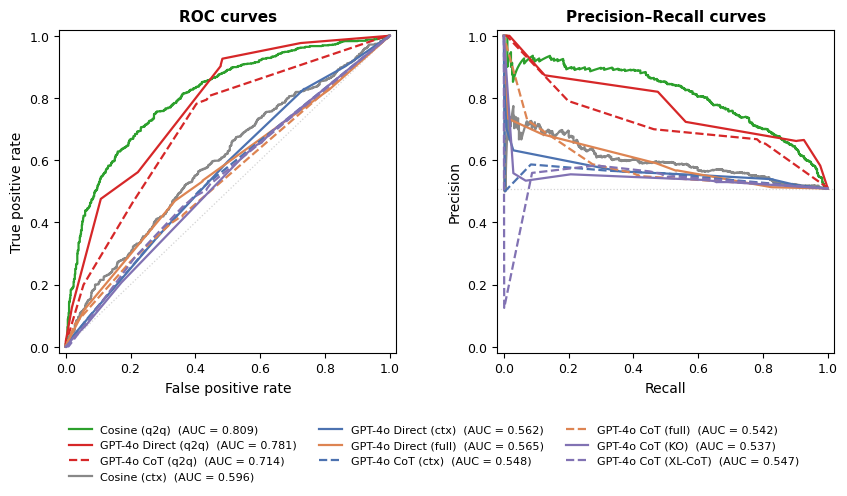

In [13]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, auc

METHODS_KO = [
    # q2q methods — stand-out colours
    ('Cosine (q2q)',          cosine_q2q_scores, '#2ca02c', '-'),
    ('GPT-4o Direct (q2q)',   gpt_q2q_scores,    '#d62728', '-'),
    ('GPT-4o CoT (q2q)',      cot_q2q_scores,    '#d62728', '--'),
    # ctx/full methods — muted colours
    ('Cosine (ctx)',           cosine_scores,     '#888888', '-'),
    ('GPT-4o Direct (ctx)',    gpt_scores,        '#4C72B0', '-'),
    ('GPT-4o Direct (full)',   gpt_full_scores,   '#DD8452', '-'),
    ('GPT-4o CoT (ctx)',       cot_scores,        '#4C72B0', '--'),
    ('GPT-4o CoT (full)',      cot_full_scores,   '#DD8452', '--'),
    ('GPT-4o CoT (KO)',        cot_ko_scores,     '#8172B3', '-'),
    ('GPT-4o CoT (XL-CoT)',    cot_xlcot_scores,  '#8172B3', '--'),
]

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(10, 4.2))
fig.subplots_adjust(wspace=0.30)

ax_roc.plot([0, 1], [0, 1], color='lightgrey', lw=0.9, linestyle=':', zorder=0)
ax_pr.axhline(y_true.mean(), color='lightgrey', lw=0.9, linestyle=':', zorder=0)

for label, scores, color, ls in METHODS_KO:
    roc_auc = roc_auc_score(y_true, scores)
    fpr, tpr, _ = roc_curve(y_true, scores)
    ax_roc.plot(fpr, tpr, linestyle=ls, color=color, lw=1.6,
                label=f'{label}  (AUC = {roc_auc:.3f})')
    prec, rec, _ = precision_recall_curve(y_true, scores)
    ax_pr.plot(rec, prec, linestyle=ls, color=color, lw=1.6)

ax_roc.set_xlabel('False positive rate', fontsize=10)
ax_roc.set_ylabel('True positive rate', fontsize=10)
ax_roc.set_title('ROC curves', fontsize=11, fontweight='bold')
ax_roc.set_xlim(-0.02, 1.02); ax_roc.set_ylim(-0.02, 1.02)
ax_roc.tick_params(labelsize=9)

ax_pr.set_xlabel('Recall', fontsize=10)
ax_pr.set_ylabel('Precision', fontsize=10)
ax_pr.set_title('Precision\u2013Recall curves', fontsize=11, fontweight='bold')
ax_pr.set_xlim(-0.02, 1.02); ax_pr.set_ylim(-0.02, 1.02)
ax_pr.tick_params(labelsize=9)

handles, labels_leg = ax_roc.get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=3, fontsize=8.0,
           framealpha=0.85, edgecolor='none', bbox_to_anchor=(0.5, -0.22))

os.makedirs('figures', exist_ok=True)
fig.savefig('figures/fig_roc_pr_korean.pdf', bbox_inches='tight', dpi=150)
plt.show()

## Save Updated Predictions

In [12]:
df['score_cosine_q2q'] = cosine_q2q_scores
df['pred_cosine_q2q']  = cosine_q2q_preds
df['score_gpt_q2q']    = gpt_q2q_scores
df['pred_gpt_q2q']     = gpt_q2q_preds
df['score_cot_q2q']    = cot_q2q_scores
df['pred_cot_q2q']     = cot_q2q_preds

df.to_csv('data/korean_predictions_v2.csv', index=False)
print('Saved: data/korean_predictions_v2.csv')

Saved: data/korean_predictions_v2.csv
